In [63]:
import pandas as pd
import numpy as np
import json
import os
from jiwer import wer, cer
from datasets import load_dataset
import re
from num2words import num2words
from scipy.stats import iqr, ttest_rel
import matplotlib.pyplot as plt
import seaborn as sns


In [19]:
def clean_transcription(sentence: str):
    """
    Function to preprocess the ground truth and predicted transcripts before computing the performance using WER, CER etc...
    Should standardize the text to lowercase, no punctuations or special characters.
    It should also map all occurrences of numbers to textual representations using library function.
    """
    sentence = str.lower(sentence)
    sentence = re.sub(r'-(?!\d)', '', sentence)             # Remove - that are not followed by a number
    sentence = re.sub(r'(?<!\d)\.|\.?(?!\d)', '', sentence) # Remove . that are not enclosed by two numbers
    sentence = re.sub(r'[^\w\s.-]', '', sentence)           # Remove all punctuation except for the - and .
    sentence = re.sub(' +', ' ', sentence)                  # Replacing all duplicate spaces with single space.
    
    sentence_copy = str(sentence)

    for s in sentence.split():
        try: 
            num = float(s)
            word_rep = str(num2words(number=num))
            sentence_copy = sentence_copy.replace(s, word_rep)
        except ValueError as e:
            continue

    return sentence_copy    

In [ ]:
ds = load_dataset("CoRal-project/coral-v3", "conversation", split="test")
ds = ds.to_pandas()

In [55]:
int8_df = pd.read_json('/root/master_thesis/thesis_multi_speaker_asr/src/hpc_results/exp_1/int8/asr_output_coral_segments.jsonl', lines=True)
fp32_df = pd.read_json('/root/master_thesis/thesis_multi_speaker_asr/src/hpc_results/exp_1/fp32/asr_output_coral_segments.jsonl', lines=True)


In [56]:
def calculate_results(df, err_type: str):
    ref_lookup = ds.set_index("id_conversation")["text"].to_dict()
    epochs = sorted(df["epoch"].unique())

    results = {epoch: [] for epoch in epochs}

    for _, row in df.iterrows():

        # concatenate references in the order given
        reference = " ".join(ref_lookup[s] for s_list in row["segment_ids"] for s in s_list)
        hypothesis = " ".join(row["hypothesis"])
        if err_type == 'wer':
            error = wer(clean_transcription(reference), clean_transcription(hypothesis))
        elif err_type == 'cer':
            error = cer(clean_transcription(reference), clean_transcription(hypothesis))
        results[row["epoch"]].append(error)

    res_df = pd.DataFrame(dict((k, pd.Series(v)) for k, v in results.items()))
    return res_df.to_numpy()

In [57]:
data_int8_cer = calculate_results(int8_df, 'cer')
data_int8_wer = calculate_results(int8_df, 'wer')

data_fp32_cer = calculate_results(fp32_df, 'cer')
data_fp32_wer = calculate_results(fp32_df, 'wer')


In [72]:
print(f'INT8 CER: {np.average(data_int8_cer):.2%}')
print(f'INT8 WER: {np.average(data_int8_wer):.2%}')
print(f'FP32 CER: {np.average(data_fp32_cer):.2%}')
print(f'FP32 WER: {np.average(data_fp32_wer):.2%}')

INT8 CER: 14.83%
INT8 WER: 24.55%
FP32 CER: 14.47%
FP32 WER: 24.06%


In [65]:
# Plot the distribution of the error rate... The difference between FP32 and INT8 for CER and WER respectively.
def plot(data_fp32,data_int8, err_type):
    epoch_avg_fp32 = np.average(data_fp32, axis=1)
    epoch_avg_int8 = np.average(data_int8, axis=1)

    diff = epoch_avg_int8 - epoch_avg_fp32
    
    mean_diff = np.mean(diff)
    std_diff = np.std(diff, ddof=1)

    cohen = mean_diff / std_diff
    print(f'Mean of difference: {mean_diff}, Standard Deviation: {std_diff} and Cohens d: {cohen}')

    iqr_diff = iqr(diff)
    bin_width = 2 * iqr_diff * ((len(diff))**(-1/3))

    sns.histplot(diff, kde=True, bins=20, binwidth=bin_width, color='purple')
    # Labels and title
    plt.xlabel(err_type)
    plt.ylabel('Frequency')
    plt.grid()
    plt.show()

Mean of difference: 0.003554059427425029, Standard Deviation: 0.018953553207893103 and Cohens d: 0.18751415043090497


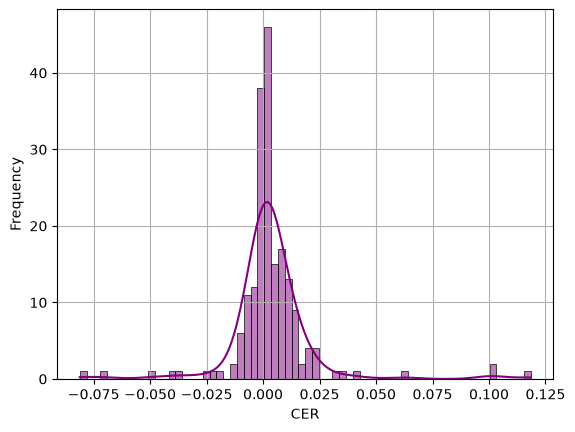

In [66]:
plot(data_int8=data_int8_cer, data_fp32=data_fp32_cer, err_type='CER')

Mean of difference: 0.004900500371151275, Standard Deviation: 0.02273111125281601 and Cohens d: 0.21558560497319215


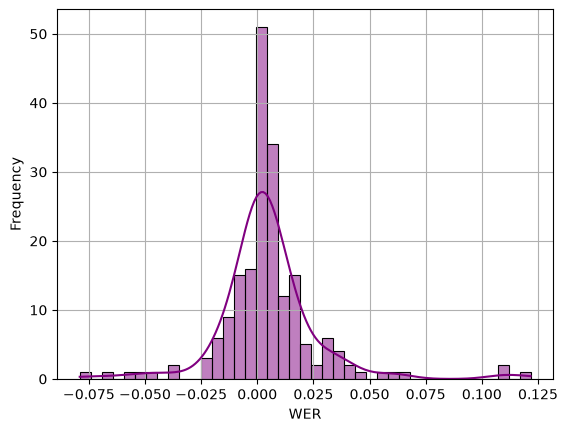

In [67]:
plot(data_int8=data_int8_wer, data_fp32=data_fp32_wer, err_type='WER')

Given that both distributions show a bell curve strongly indicates a normal distribution of the udnerlying data samples. Therefore, I will test the results with a paired t-test.

In [69]:
def paired_ttest(data_fp32, data_int8):
    epoch_mean_fp32 = np.mean(data_fp32, axis=1)
    epoch_mean_int8 = np.mean(data_int8, axis=1)

    res = ttest_rel(epoch_mean_int8,
                    epoch_mean_fp32,
                    alternative="greater")
    print(res.statistic)
    print(res.pvalue)

In [70]:
paired_ttest(data_fp32=data_fp32_cer, data_int8=data_int8_cer)
paired_ttest(data_fp32=data_fp32_wer, data_int8=data_int8_wer)

2.611769894667957
0.0048579158433598515
3.002760013038256
0.0015147842952830646
